## Cost Landscape Exploration

&nbsp;

### Read the csv containing results from cost exploration:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_1 = pd.read_csv("cost_exploration/yahpo_costs_test8.csv")
df_1["val_accuracy_scaled"] = df_1["val_accuracy"] * 0.01

df_2 = pd.read_csv("cost_exploration/yahpo_costs_train20.csv")
df_2["val_accuracy_scaled"] = df_2["val_accuracy"] * 0.01

### Get percentiles:

In [3]:
df_1["time"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

count     8000.000000
mean       620.889716
std        969.755156
min         15.017196
10%         68.109850
25%        121.882799
50%        224.995178
75%        649.453156
90%       1807.979602
95%       2747.173816
max      12905.822266
Name: time, dtype: float64

In [4]:
df_2["time"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

count    20000.000000
mean       269.836260
std        794.825975
min          8.320948
10%         49.826944
25%         72.275209
50%        123.880032
75%        245.530502
90%        599.726196
95%        866.830728
max      38462.175781
Name: time, dtype: float64

&nbsp;

### Grouping by instance:

In [5]:
df_1.groupby("instance")["time"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
instance,,,,,,,,,,,
168331,1000.0,261.403632,321.478688,68.595551,108.699126,138.103615,183.495033,265.011261,430.413809,593.416144,4461.842773
168335,1000.0,389.636991,776.384528,24.011532,138.866682,167.504295,206.358078,334.143547,651.347711,1025.258307,12905.822266
168868,1000.0,272.428608,345.912468,21.109638,77.569241,109.145357,168.138428,290.590729,536.861688,783.248437,3923.659668
168908,1000.0,1925.064933,1045.960645,84.832764,149.415843,1457.640930,2275.448486,2785.964111,3027.251001,3117.824036,4339.551758
168910,1000.0,531.442615,295.031958,79.193520,132.929855,330.241112,542.834045,730.435669,849.893378,944.184613,2444.404053
189354,1000.0,1335.116189,1574.861450,240.911667,492.515585,558.146744,765.960510,1342.404663,2633.519385,4592.973926,12834.927734
189862,1000.0,133.581088,120.661976,15.501077,45.308442,61.050412,90.882671,151.162487,286.480875,377.849321,1139.773438
189865,1000.0,118.443673,111.011190,15.017196,39.155481,50.394217,79.660671,141.528790,253.327753,353.183627,963.721497


In [6]:
df_2.groupby("instance")["time"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
instance,,,,,,,,,,,
3945,1000.0,245.770203,247.261699,43.542484,75.011228,115.062094,183.171516,269.809990,476.969037,645.526889,2878.204346
7593,1000.0,1681.759727,3056.204188,425.839386,575.754144,685.346848,929.247406,1502.606689,2729.530981,4362.041650,38462.175781
34539,1000.0,132.062786,117.841198,31.686695,60.463409,74.757715,91.512974,138.414936,246.966591,360.977068,1176.124512
126025,1000.0,160.787477,190.499126,34.525837,66.854827,77.457756,98.800476,168.295307,312.944446,459.609424,3381.067139
126026,1000.0,169.977794,159.756379,23.437008,55.808526,76.910429,114.610287,192.621143,368.577408,501.898000,1455.452271
126029,1000.0,160.909893,253.527423,35.474079,63.894086,74.764683,98.927372,164.093765,312.692621,474.291241,6160.429199
146212,1000.0,205.127815,264.718220,16.739368,41.628434,64.729376,116.091911,218.136467,477.168866,703.624121,2685.863525
167104,1000.0,87.340566,100.822390,11.267465,21.934328,28.828032,52.995600,94.602774,199.057886,311.438081,907.464417
167149,1000.0,92.167025,84.189011,8.320948,27.951886,38.674040,62.675318,108.673330,209.225531,268.102661,895.898682


&nbsp;

### Correlations:

In [7]:
cols = [
    "time",
    "val_accuracy",
    "batch_size",
    "learning_rate",
    "max_dropout",
    "max_units",
    "momentum",
    "num_layers",
    "weight_decay",
]

df_together = pd.concat([df_1, df_2], ignore_index=True)

df_together[cols].corr(numeric_only=True)["time"].sort_values(ascending=False)

time             1.000000
num_layers       0.205064
max_units        0.177362
weight_decay     0.039667
learning_rate    0.034697
momentum         0.016446
max_dropout     -0.029033
batch_size      -0.058044
val_accuracy    -0.088610
Name: time, dtype: float64

&nbsp;

### Count how many evaluations you could take under different budgets:

In [18]:
def evals_until_budget(costs, budget, n_repeats=1000, seed=0):
    rng = np.random.default_rng(seed)
    counts = []

    costs = np.asarray(costs)

    for _ in range(n_repeats):
        order = rng.permutation(costs)
        cumulative = np.cumsum(order)
        count = np.searchsorted(cumulative, budget, side="right")
        counts.append(count)

    return np.array(counts)


budgets = [2500, 4000, 5000, 8000, 10000]
rows = []

for instance, g in df_1.groupby("instance"):
    for budget in budgets:
        counts = evals_until_budget(g["time"].values, budget)
        rows.append(
            {
                "instance": instance,
                "budget": budget,
                "mean_evals": counts.mean(),
                "median_evals": np.median(counts),
                "p10_evals": np.quantile(counts, 0.1),
                "p90_evals": np.quantile(counts, 0.9),
            }
        )

eval_counts = pd.DataFrame(rows)
eval_counts

,instance,budget,mean_evals,median_evals,p10_evals,p90_evals
0,168331,2500,9.848,10.0,6.0,13.0
1,168331,4000,15.637,16.0,10.0,20.0
2,168331,5000,19.413,20.0,12.9,25.0
3,168331,8000,30.655,31.0,22.0,38.0
4,168331,10000,38.344,39.0,28.0,47.0
5,168335,2500,7.386,8.0,3.0,11.0
6,168335,4000,11.387,12.0,5.0,16.0
7,168335,5000,14.006,15.0,7.0,20.0
8,168335,8000,21.911,23.0,12.0,30.0
9,168335,10000,27.094,28.0,16.0,37.0


&nbsp;

&nbsp;

&nbsp;

&nbsp;

### Plots:

#### Distributions:

##### Median Evaluation Distribution by Instance (Train20):

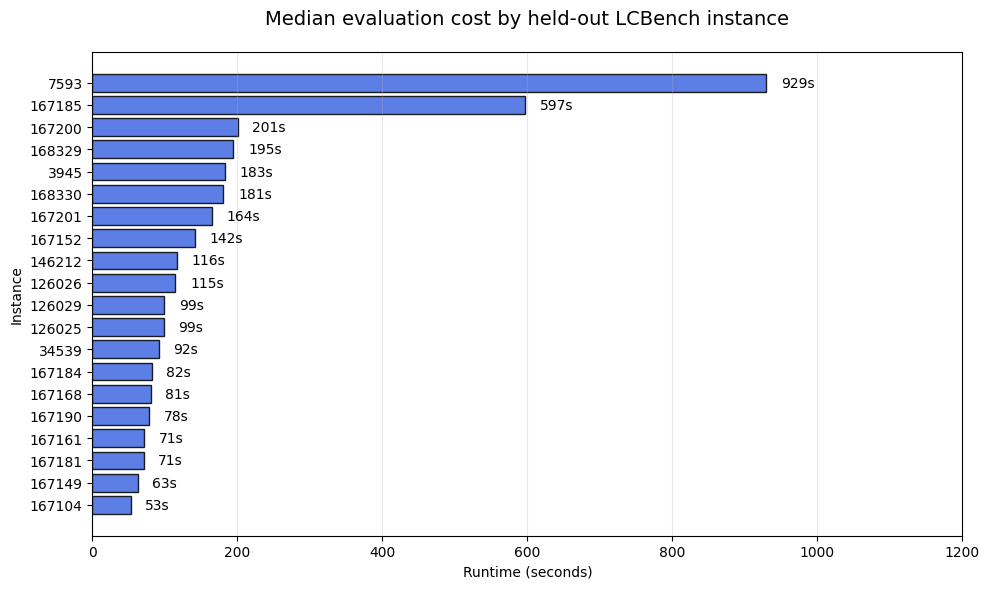

In [8]:
median_times = (
    df_2.groupby("instance")["time"]
    .median()
    .sort_values(ascending=True)   # ascending=True puts smallest on top (like your plot)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    y=median_times.index.astype(str), 
    width=median_times.values, 
    color='royalblue',
    edgecolor='black',
    alpha=0.85
)

plt.title("Median evaluation cost by held-out LCBench instance", fontsize=14, pad=20)
plt.xlabel("Runtime (seconds)")
plt.ylabel("Instance")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'{width:.0f}s', 
             va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.xlim([0, 1200])
plt.tight_layout()
plt.show()

##### Median Evaluation Distribution by Instance (Test8):

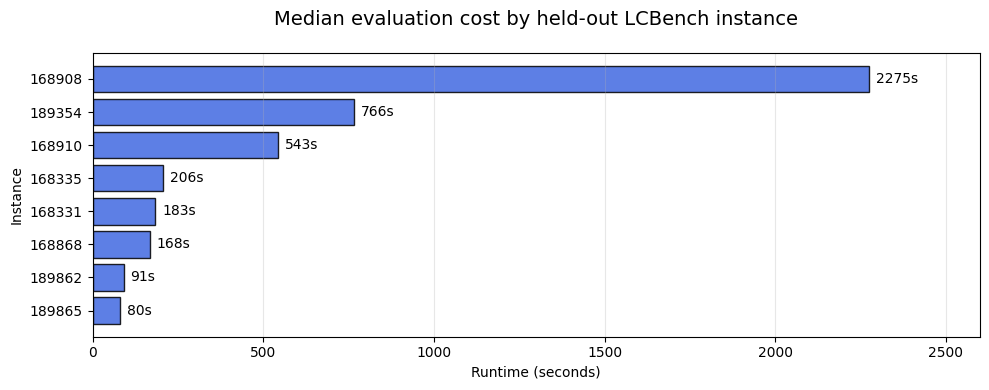

In [9]:
median_times = (
    df_1.groupby("instance")["time"]
    .median()
    .sort_values(ascending=True)   # ascending=True puts smallest on top (like your plot)
)

plt.figure(figsize=(10, 4))

bars = plt.barh(
    y=median_times.index.astype(str), 
    width=median_times.values, 
    color='royalblue',
    edgecolor='black',
    alpha=0.85
)

plt.title("Median evaluation cost by held-out LCBench instance", fontsize=14, pad=20)
plt.xlabel("Runtime (seconds)")
plt.ylabel("Instance")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'{width:.0f}s', 
             va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.xlim([0, 2600])
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Mean Evaluation Distribution by Instance (Train20):

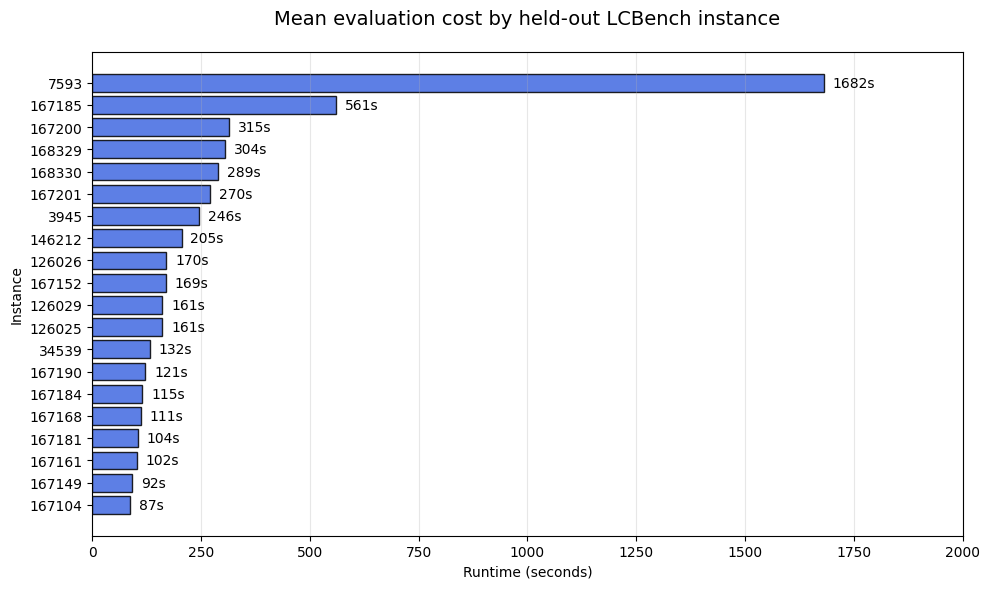

In [10]:
mean_times = (
    df_2.groupby("instance")["time"]
    .mean()
    .sort_values(ascending=True)   # ascending=True puts smallest on top (like your plot)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    y=mean_times.index.astype(str), 
    width=mean_times.values, 
    color='royalblue',
    edgecolor='black',
    alpha=0.85
)

plt.title("Mean evaluation cost by held-out LCBench instance", fontsize=14, pad=20)
plt.xlabel("Runtime (seconds)")
plt.ylabel("Instance")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'{width:.0f}s', 
             va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.xlim([0, 2000])
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Mean Evaluation Distribution by Instance (Test8):

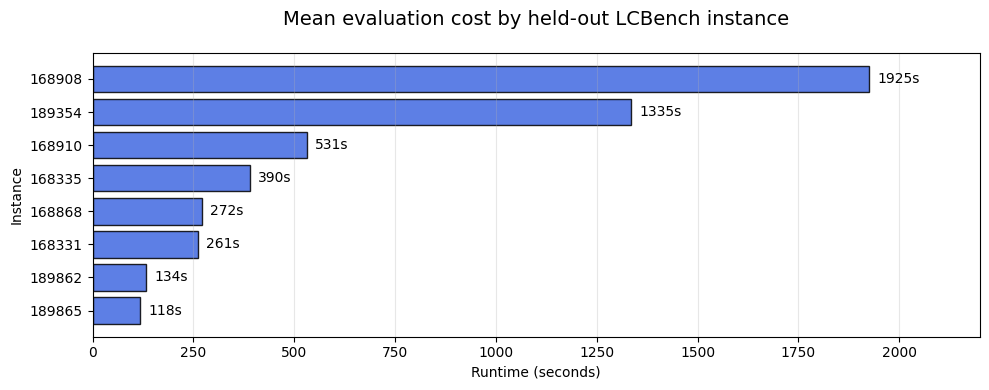

In [11]:
mean_times = (
    df_1.groupby("instance")["time"]
    .mean()
    .sort_values(ascending=True)   # ascending=True puts smallest on top (like your plot)
)

plt.figure(figsize=(10, 4))

bars = plt.barh(
    y=mean_times.index.astype(str), 
    width=mean_times.values, 
    color='royalblue',
    edgecolor='black',
    alpha=0.85
)

plt.title("Mean evaluation cost by held-out LCBench instance", fontsize=14, pad=20)
plt.xlabel("Runtime (seconds)")
plt.ylabel("Instance")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'{width:.0f}s', 
             va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.xlim([0, 2200])
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Cost Distribution - Train20:

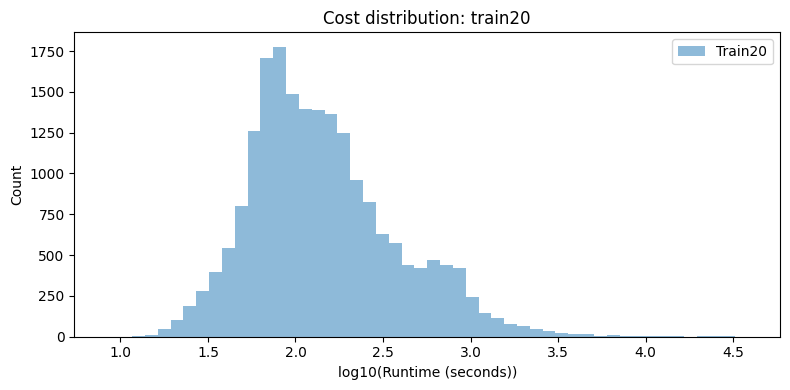

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(np.log10(df_2["time"]), bins=50, alpha=0.5, label="Train20")
plt.xlabel("log10(Runtime (seconds))")
plt.ylabel("Count")
plt.title("Cost distribution: train20")
plt.legend()
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Cost Distribution - Test8:

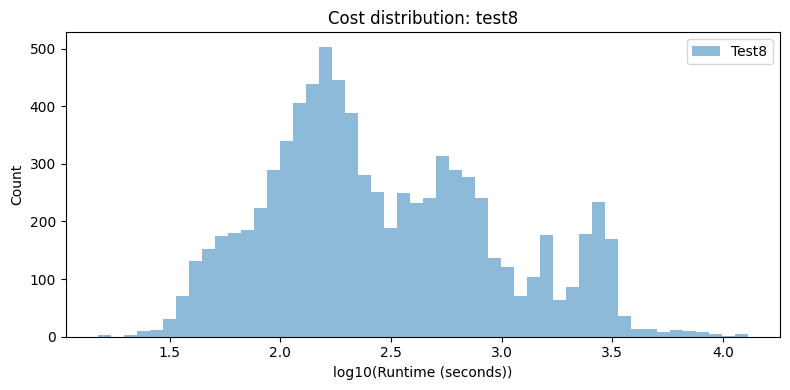

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(np.log10(df_1["time"]), bins=50, alpha=0.5, label="Test8")
plt.xlabel("log10(Runtime (seconds))")
plt.ylabel("Count")
plt.title("Cost distribution: test8")
plt.legend()
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Cost Distribution - Train20 vs Test8:

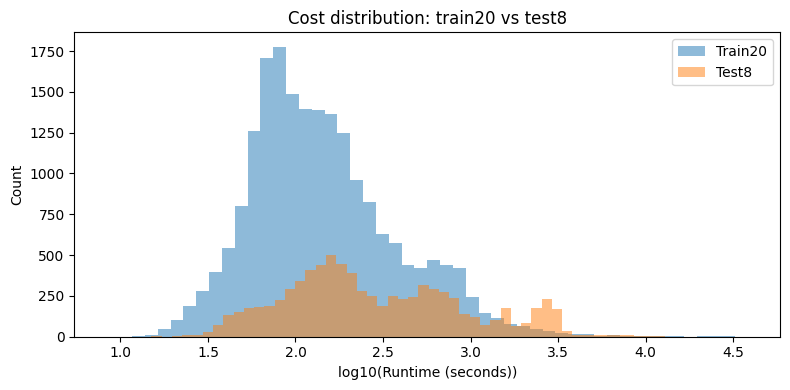

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(np.log10(df_2["time"]), bins=50, alpha=0.5, label="Train20")
plt.hist(np.log10(df_1["time"]), bins=50, alpha=0.5, label="Test8")
plt.xlabel("log10(Runtime (seconds))")
plt.ylabel("Count")
plt.title("Cost distribution: train20 vs test8")
plt.legend()
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Cost Distribution - Train and Test:

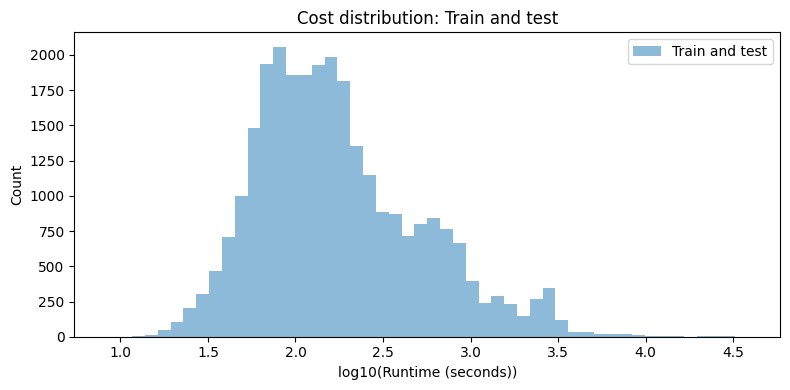

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 4))
plt.hist(np.log10(df_together["time"]), bins=50, alpha=0.5, label="Train and test")
plt.xlabel("log10(Runtime (seconds))")
plt.ylabel("Count")
plt.title("Cost distribution: Train and test")
plt.legend()
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Expected number of evaluations under different budgets (per instance in test):

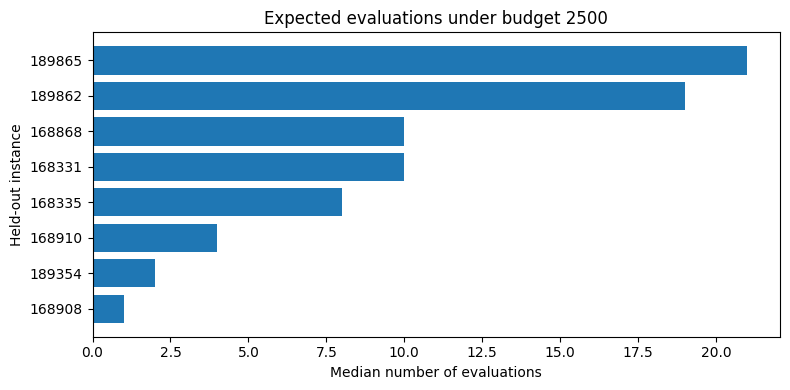

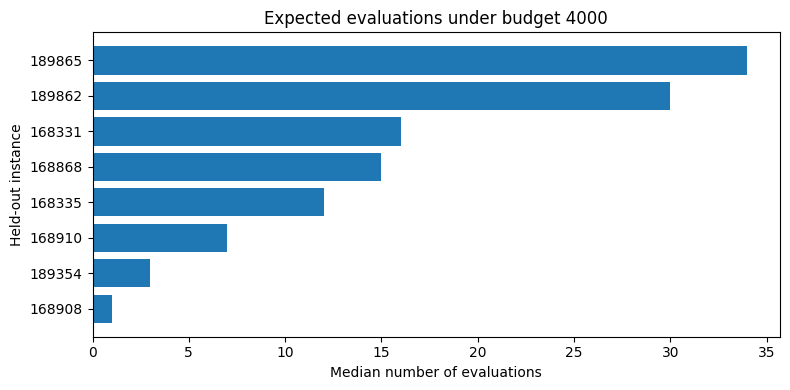

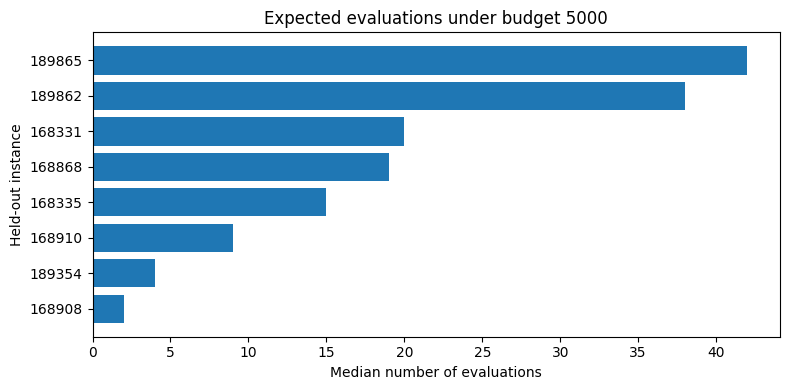

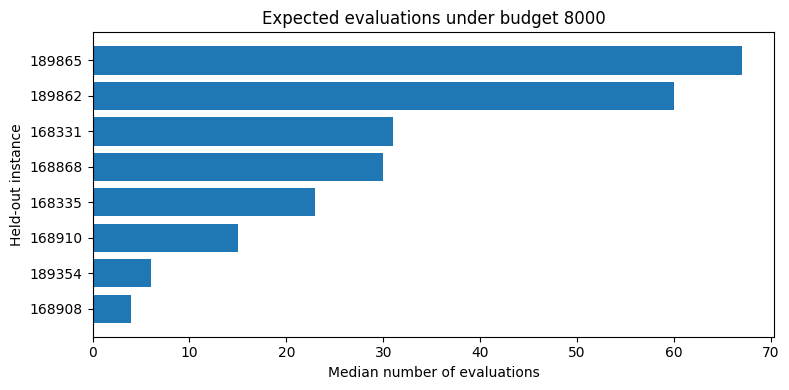

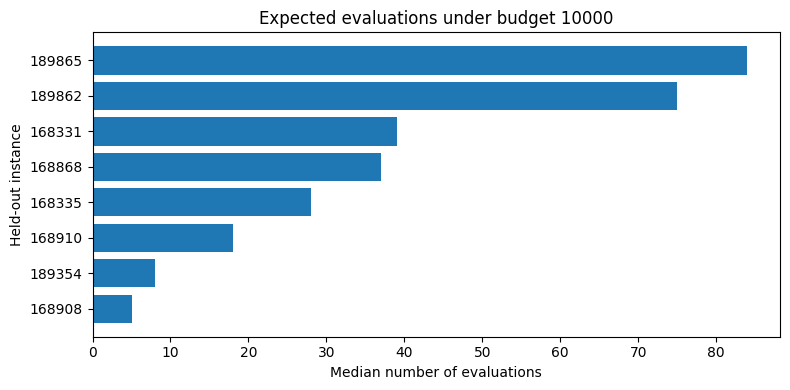

In [19]:
for budget in budgets:
    sub = eval_counts[eval_counts["budget"] == budget].sort_values("median_evals")

    plt.figure(figsize=(8, 4))
    plt.barh(sub["instance"].astype(str), sub["median_evals"])
    plt.xlabel("Median number of evaluations")
    plt.ylabel("Held-out instance")
    plt.title(f"Expected evaluations under budget {budget}")
    plt.tight_layout()
    plt.show()

&nbsp;

&nbsp;




##### Cost vs validation accuracy scatter (Test):

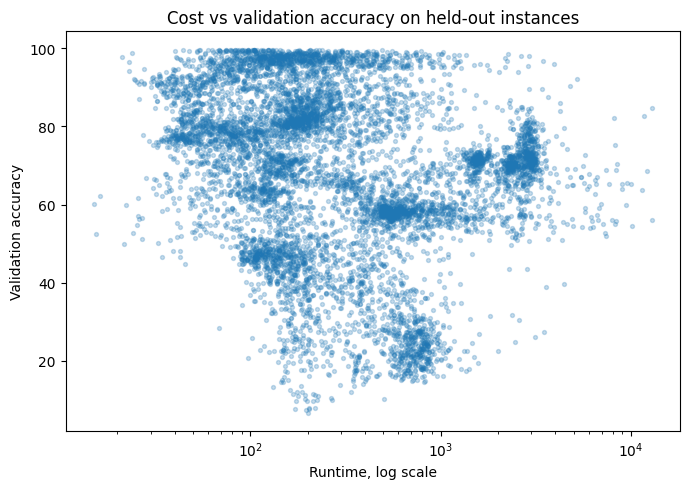

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(df_1["time"], df_1["val_accuracy"], alpha=0.25, s=8)
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title("Cost vs validation accuracy on held-out instances")
plt.tight_layout()
plt.show()

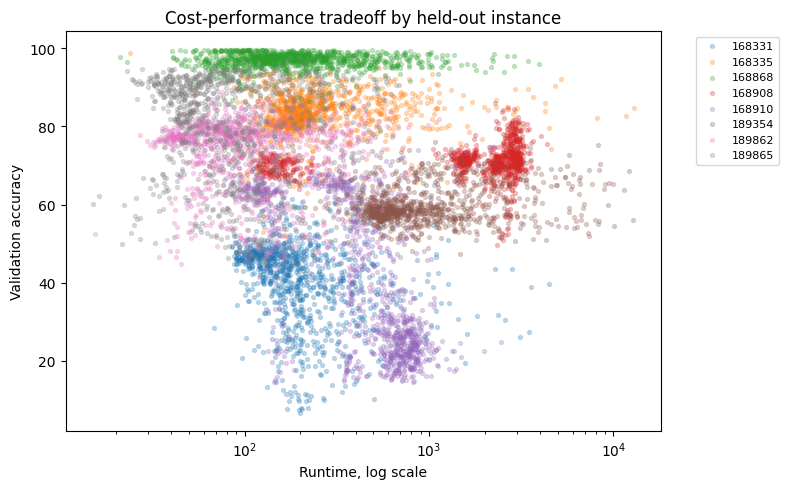

In [21]:
plt.figure(figsize=(8, 5))
for instance, g in df_1.groupby("instance"):
    plt.scatter(g["time"], g["val_accuracy"], alpha=0.25, s=8, label=str(instance))

plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title("Cost-performance tradeoff by held-out instance")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;

##### Pareto frontier plot

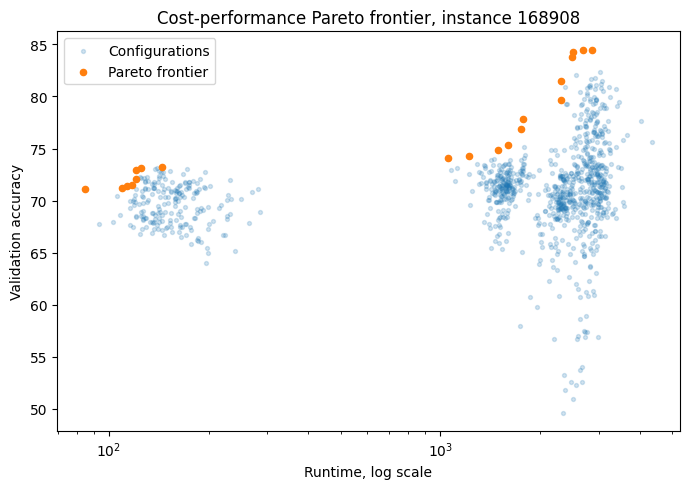

In [22]:
def pareto_frontier(df, cost_col="time", obj_col="val_accuracy"):
    d = df.sort_values(cost_col).copy()
    best_so_far = -np.inf
    keep = []

    for _, row in d.iterrows():
        if row[obj_col] > best_so_far:
            keep.append(True)
            best_so_far = row[obj_col]
        else:
            keep.append(False)

    return d[keep]


instance = "168908"
g = df_1[df_1["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

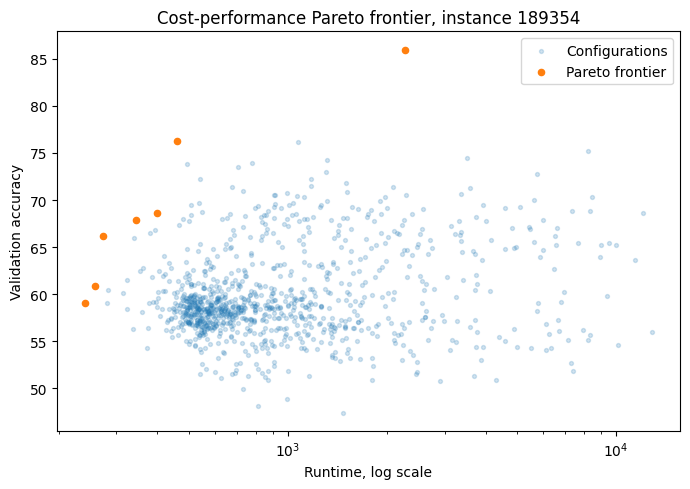

In [23]:
instance = "189354"
g = df_1[df_1["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

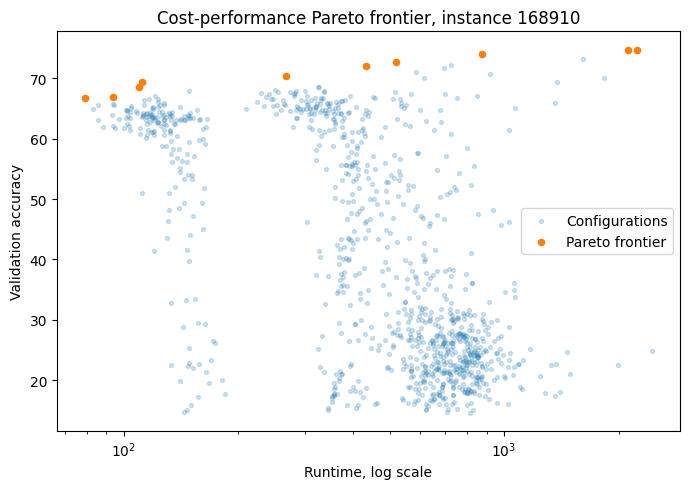

In [24]:
instance = "168910"
g = df_1[df_1["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;

##### Hyperparameter impact on cost

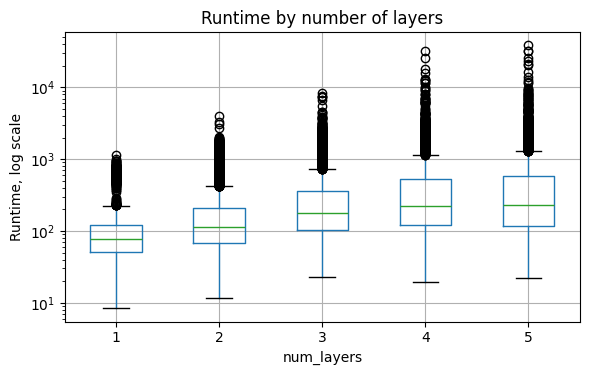

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
df_together.boxplot(column="time", by="num_layers", ax=ax)
ax.set_yscale("log")
ax.set_title("Runtime by number of layers")
ax.set_xlabel("num_layers")
ax.set_ylabel("Runtime, log scale")
plt.suptitle("")
plt.tight_layout()
plt.show()

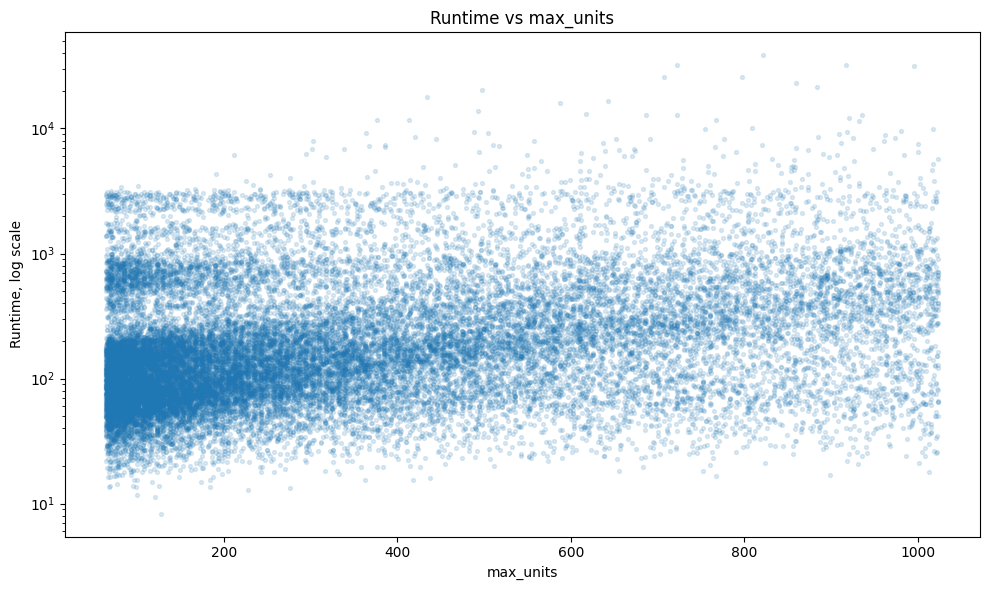

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df_together["max_units"], df_together["time"], alpha=0.15, s=8)
plt.yscale("log")
plt.xlabel("max_units")
plt.ylabel("Runtime, log scale")
plt.title("Runtime vs max_units")
plt.tight_layout()
plt.show()

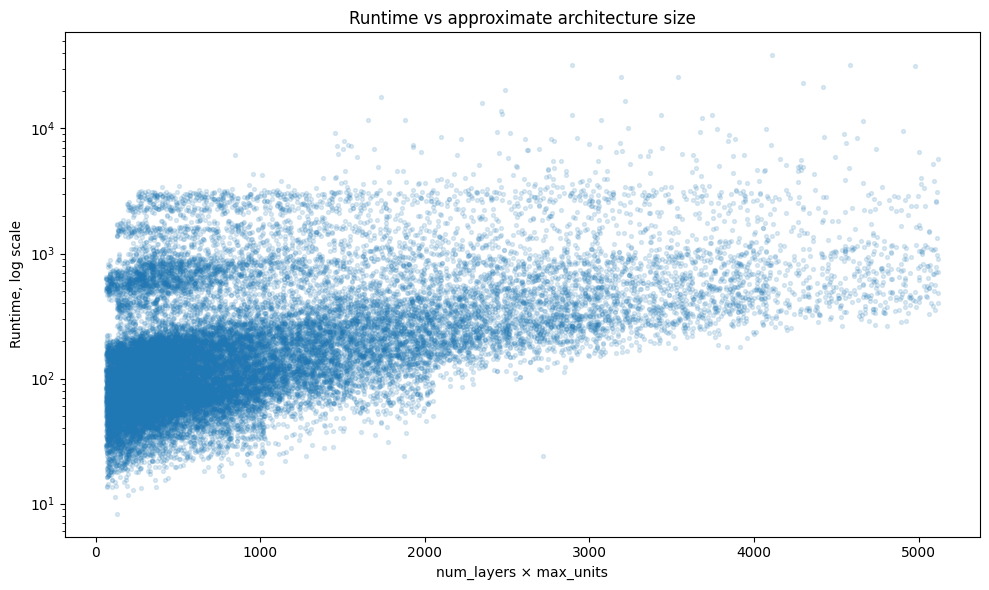

In [30]:
df_together["architecture_size"] = df_together["num_layers"] * df_together["max_units"]

plt.figure(figsize=(10, 6))
plt.scatter(df_together["architecture_size"], df_together["time"], alpha=0.15, s=8)
plt.yscale("log")
plt.xlabel("num_layers × max_units")
plt.ylabel("Runtime, log scale")
plt.title("Runtime vs approximate architecture size")
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;

##### Validation accuracy distribution: train20 vs test8

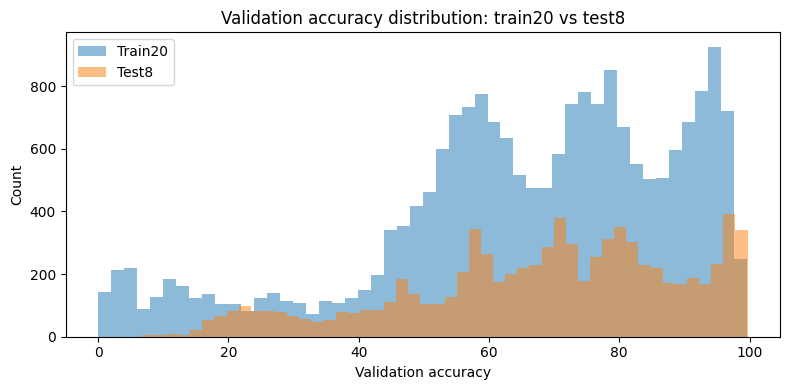

In [32]:
plt.figure(figsize=(8, 4))
plt.hist(df_2["val_accuracy"], bins=50, alpha=0.5, label="Train20")
plt.hist(df_1["val_accuracy"], bins=50, alpha=0.5, label="Test8")
plt.xlabel("Validation accuracy")
plt.ylabel("Count")
plt.title("Validation accuracy distribution: train20 vs test8")
plt.legend()
plt.tight_layout()
plt.show()